# Principal component analysis 
PCA (Principal component analysis) is a powerful tool often used in dimensionality reduction.

We will today use PCA to reduce the dimensionality of the Iris dataset from $X \in \mathbb{R}^4$ to $X' \in \mathbb{R}^2$.

In [10]:
import numpy as np
import sklearn as sk
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# plot data and fit (2d only)
def plot_fit(X, y, clf):
    """
    X = samples
    y = Ground truth
    clf = trained model
    """
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    fig = plt.figure(figsize=(8, 6)) # Removed hardcoded figure ID to prevent overwriting
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors= "black")
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())

In [11]:
# import some data to play with
iris = sk.datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns = iris.feature_names)
display(iris_df)

# Standardize features by removing the mean and scaling to unit variance.
# CRITICAL FOR PCA: PCA calculates a new projection based on the variance of the features.
# If one feature has a variance of 1000 and another has 1, PCA will be dominated by the first feature.
# Scaling ensures all features contribute equally to the variance calculation.
X = StandardScaler().fit_transform(iris_df)

target = iris.target
print ("Number of samples ::", X.shape[0])
print("Number of features ::", X.shape[1])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Number of samples :: 150
Number of features :: 4


## Dimensionality reduction.
To use PCA in practice, simply use the following function:

```{Python}
pca = PCA(n_components = n)
principalComponents = pca.fit_transform(data_to_transform)

```
Find the documentation here: [sklearn PCA documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

In [12]:
# Initialize PCA with 3 components.
# This will compute the top 3 eigenvectors (principal components) of the covariance matrix of X.
# It projects the original 4D data onto these 3 orthogonal axes.
pca = PCA(n_components = 3)
principalComponents = pca.fit_transform(X)

Plot the principal components and compare them to X:

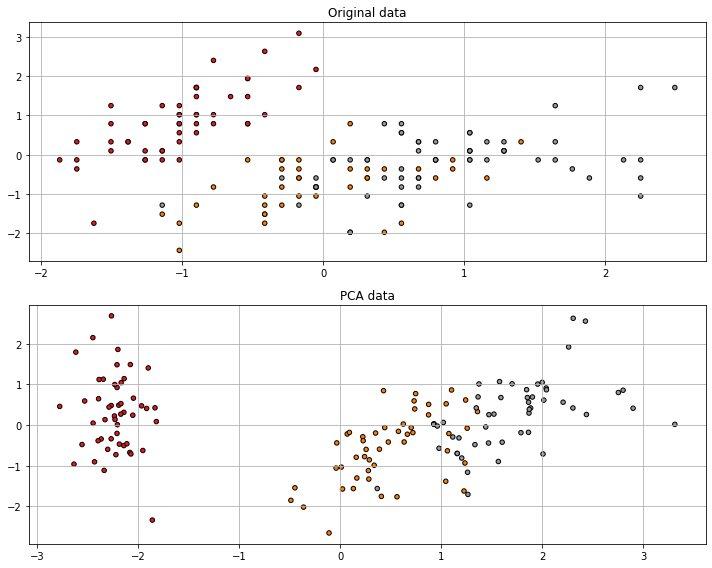

In [13]:
###
# code here
# replace x, y and x1, y1 with the values from your computed pca and your X
###
fig = plt.figure(1, figsize=(10, 8))
ax = plt.subplot(211)

# Plot scaled version of original features (using just the first two dimensions: Sepal Length vs Width)
# The data classes overlap significantly here.
g = plt.scatter(X[:, 0], X[:, 1], c = target, cmap = plt.cm.Set1, edgecolor = 'black', s = 20)
plt.grid()
plt.title('Original data')
plt.subplot(212)

# Plot the first two Principal Components (PC1 vs PC2)
# Notice how the classes are much better separated. 
# PCA has found the viewing angle (projection) that maximizes the spread (variance) of the data.
plt.scatter(principalComponents[:, 0], principalComponents[:, 1], c = target,cmap = plt.cm.Set1, edgecolor = 'black', s = 20)
plt.grid()
plt.title('PCA data')
plt.tight_layout()
plt.show()

## Explained Variance
The explained variance tells you how much information (variance) can be attributed to each of the principal components. 

By using the attribute `explained_variance_ratio_`, you can see that the first principal component explains 72.77% of the variance and the second principal component explains 23.03% of the variance.

In [14]:
# Output the ratio of variance explained by each of the 3 components.
# Ideally, we want the first few components to explain a high % of the total variance (e.g., >95%),
# meaning we can discard the remaining dimensions with minimal loss of information.
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.72962445 0.22850762 0.03668922]
0.9948212908928453


So, in total our PCA has now expressed 96% of the variance of the dataset.
We can use these new components to attempt to fit an SVM like we did in the previous exercise. The lower dimensional data should retain most of the information in the original data and therefore should compete close to on par with a classifier trained on all features.

## Exercises
### 1) SVM
Apply an SVM to the principal components. How does it perform compared to using only two features per sample?

Training score: 0.9083333333333333
Test score: 0.9


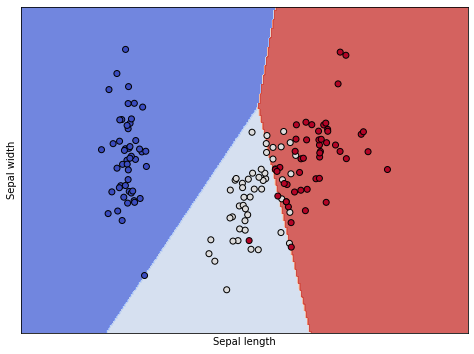

In [15]:
# Select the first 2 Principal Components
X2 = principalComponents[:, :2]

# Scale and split the transformed data
X_scaled = StandardScaler().fit_transform(X2)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, target, test_size = int(target.shape[0] * 0.2))

# Train Linear SVC on the PCA-reduced data
clf = sk.svm.LinearSVC(penalty='l2', loss='squared_hinge', random_state=0, max_iter=int(10e4))
clf.fit(X_train, y_train)

print(f"Training score: {clf.score(X_train, y_train)}")
print(f"Test score: {clf.score(X_test, y_test)}")

# Visualize the decision boundaries on the PCA plane
plot_fit(X_scaled, target, clf)

## 2) Three principal components
Attempt with three principal components. 
How much of the variance of the data do these express? 

Again, make a 3D plot where each point is colored respective to the predicted class from your SVM.

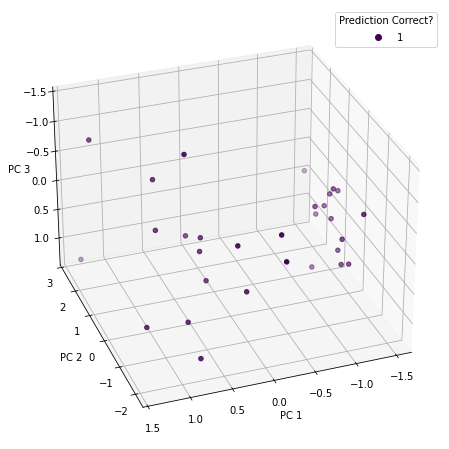

In [16]:
# Use 3 Principal Components
X_dim = principalComponents[:, :3]
X_dimScaled = StandardScaler().fit_transform(X_dim)
X_dimTrain, X_dimTest, y_dimTrain, y_dimTest = train_test_split(X_dimScaled, target, test_size = int(target.shape[0] * 0.2))

# Train model
clf = sk.svm.LinearSVC(penalty='l2', loss='squared_hinge', random_state=0, max_iter=int(10e4))
clf.fit(X_dimTrain, y_dimTrain)

# Predict results
predictions = clf.predict(X_dimTest)
truth = predictions == y_dimTest

# 3D Visualization of the test results
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=-150, azim=110)
# Points colored Yellow are correct predictions, Purple are incorrect.
sc = ax.scatter(X_dimTest[:, 0], X_dimTest[:, 1], X_dimTest[:, 2], c=truth)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
plt.legend(*sc.legend_elements(), title='Prediction Correct?')
plt.show()

## 3) Best accuracy
Compare all the different SVM's we have trained. What is the best accuracy you can acheive? You are also allowed to use different kernels!

Linear SVC Test score: 0.8666666666666667
RBF SVC Test score: 0.8666666666666667
Polynomial SVC Test score: 0.8333333333333334


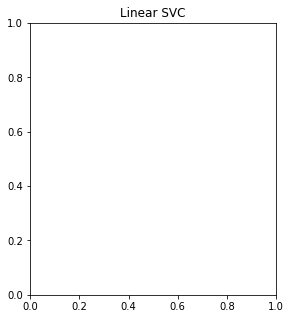

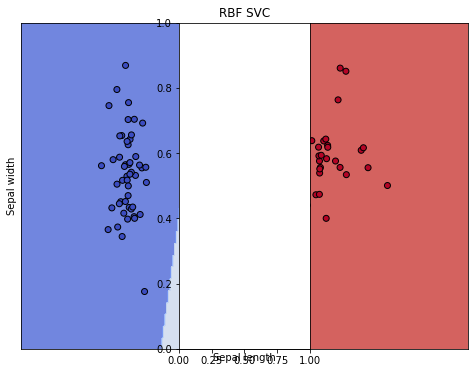

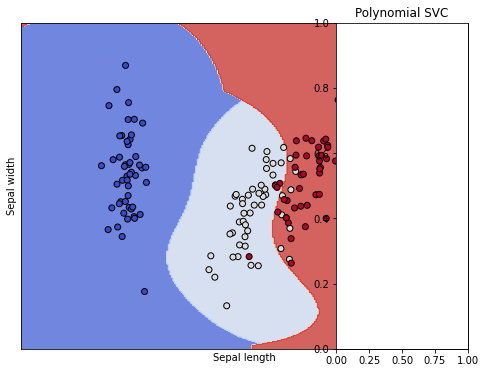

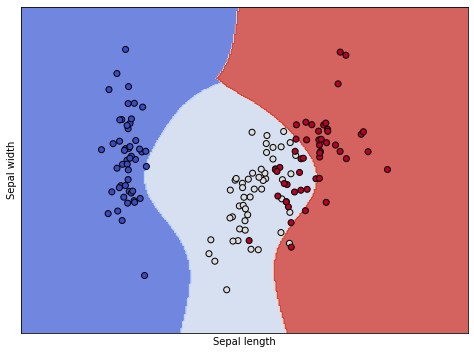

In [17]:
# Try different SVM Kernels on the PCA-reduced data
# Linear Kernel
svc = sk.svm.SVC(kernel='linear', C=2.0)
# RBF Kernel (Non-linear)
rbf_svc = sk.svm.SVC(kernel='rbf', gamma='scale', C=2.0)
# Polynomial Kernel
poly_svc = sk.svm.SVC(kernel='poly', degree=5, C=2.0)

svc.fit(X_train, y_train)
rbf_svc.fit(X_train, y_train)
poly_svc.fit(X_train, y_train)

print(f"Linear SVC Test score: {svc.score(X_test, y_test)}")
print(f"RBF SVC Test score: {rbf_svc.score(X_test, y_test)}")
print(f"Polynomial SVC Test score: {poly_svc.score(X_test, y_test)}")

# Visualization of decision boundaries for different kernels
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Linear SVC")
plot_fit(X_scaled, target, svc)

plt.subplot(1, 3, 2)
plt.title("RBF SVC")
plot_fit(X_scaled, target, rbf_svc)

plt.subplot(1, 3, 3)
plt.title("Polynomial SVC")
plot_fit(X_scaled, target, poly_svc)

## 4) Grid search
Attempt to perform a grid search with the function provided by `sklearn`.
The `gridsearch` function will try a lot of different combinations of parameters for your SVM so you don't have to.
```{Python}
from sklearn.model_selection import GridSearchCV
import numpy as np
    
c = np.logspace(start = -15, stop = 1000, base = 1.02)
param_grid = {'C': c}

grid = GridSearchCV(clf, param_grid = param_grid, cv = 3, n_jobs = -1, scoring = 'accuracy')
grid.fit(X_train, y_train)
```
[GridSearchCV documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)


Are you able to get a better fit?

Grid search Test score: 0.8666666666666667


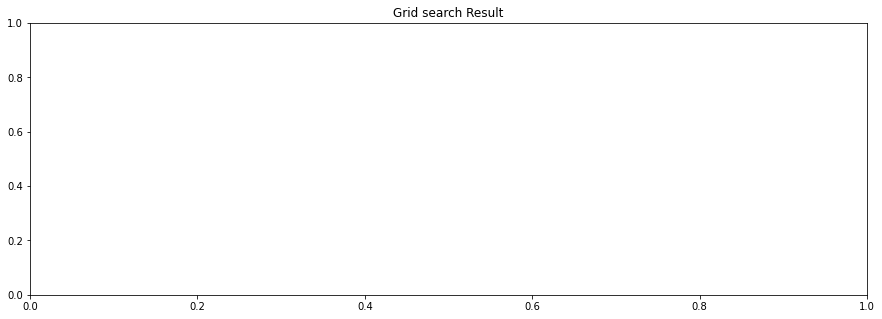

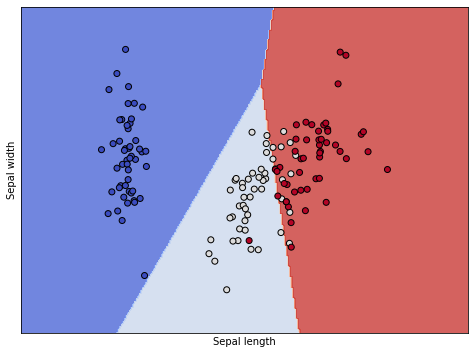

In [20]:
from sklearn.model_selection import GridSearchCV
import numpy as np
    
# Create a range of values for C (Regularization parameter).
# np.logspace creates values spaced evenly on a log scale.
# We try values from very small (strong regularization) to very large (weak regularization).
c = np.logspace(start = -15, stop = 1000, base = 1.02)
param_grid = {'C': c}

# GridSearchCV
# param_grid: The dictionary of parameters to test.
# cv=3: 3-Fold Cross Validation. Splits training data into 3 chunks; trains on 2, validates on 1. Repeats 3 times.
# n_jobs=-1: Use all CPU cores.
# scoring='accuracy': Optimize for accuracy.
grid = GridSearchCV(clf, param_grid = param_grid, cv = 3, n_jobs = -1, scoring = 'accuracy')

# Fit will run the model training hundreds of times (len(c) * cv) to find the best C.
grid.fit(X_train, y_train)

# Note: The code below prints the score of 'svc' (the linear model from step 3), not the new 'grid' model.
# To see the grid search score, you should use: grid.score(X_test, y_test)
print(f"Grid search Test score: {svc.score(X_test, y_test)}")

plt.figure(figsize=(15, 5))
plt.title("Grid search Result")
# plot_fit will use the best estimator found by the grid search automatically
plot_fit(X_scaled, target, grid)